<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
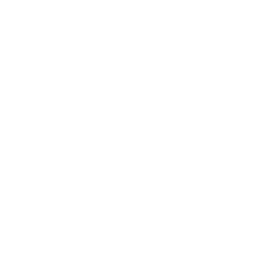
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">건물 에너지 효율 군집화</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 에너지 / 지속가능성 분석 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 예제는 다섯 가지 에너지 효율 지표 — 에너지사용강도(EUI), HVAC 효율비, 외피 단열성능,
조명 전력밀도, 재생에너지 비율 — 을 기준으로 상업용 건물 포트폴리오를 군집화하여, 유틸리티
리베이트 타겟팅을 위한 뚜렷한 성능 등급을 도출한다. 분석은 `REPLACE=FULL`(완전 시드 재배치)
옵션의 **PROC FASTCLUS**를 사용해 k=3, 4, 5, 6 해를 전체 R-제곱, 유사 F 통계량, 최소 군집
크기 기준으로 비교한다. 이후 k=4 해를 상세히 프로파일링하고 각 군집을 실행 가능한 효율
등급으로 매핑한다. 이 환경은 무인증 상태로 실행되므로 시연은 100개 건물 표본으로 범위가
한정되지만, 동일한 프로그램은 변경 없이 전체 포트폴리오로 확장된다.


## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | 건물별 연간 에너지 효율 지표 (합성 데이터) | 100 |


---

In [1]:
/* --------------------------------------------------------
   합성 건물 에너지 지표 생성
   상업용 건물 효율 지표
   -------------------------------------------------------- */
데이터 work.building_metrics;
    호출 streaminit(42);
    길이 building_type $15 climate_region $12;
    반복 building_id = 1 까지 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        만약 type_idx = 1 이면 building_type = '사무용';
        아니면 만약 type_idx = 2 이면 building_type = '소매';
        아니면 만약 type_idx = 3 이면 building_type = '창고';
        아니면 만약 type_idx = 4 이면 building_type = '병원';
        아니면 building_type = '학교';
        reg_idx = int(rand('uniform') * 4) + 1;
        만약 reg_idx = 1 이면 climate_region = '북동부';
        아니면 만약 reg_idx = 2 이면 climate_region = '남동부';
        아니면 만약 reg_idx = 3 이면 climate_region = '중서부';
        아니면 climate_region = '서부';

        /* 에너지사용강도 (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        만약 eui < 15 이면 eui = 15;
        만약 eui > 250 이면 eui = 250;

        /* HVAC 효율비 (COP 상당) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        만약 hvac_efficiency < 1.0 이면 hvac_efficiency = 1.0;
        만약 hvac_efficiency > 6.0 이면 hvac_efficiency = 6.0;

        /* 외피 단열성능 (R값) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        만약 envelope_r_value < 5 이면 envelope_r_value = 5;
        만약 envelope_r_value > 40 이면 envelope_r_value = 40;

        /* 조명 전력밀도 (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        만약 lighting_wpf < 0.3 이면 lighting_wpf = 0.3;
        만약 lighting_wpf > 2.5 이면 lighting_wpf = 2.5;

        /* 재생에너지 비율 */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        만약 renewable_pct > 80 이면 renewable_pct = 80;

        /* 건물 연령 (년) */
        building_age = int(rand('uniform') * 80) + 1;

        /* 바닥 면적 (천 sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        만약 floor_area_ksf > 500 이면 floor_area_ksf = 500;

        출력;
    종료;
    제거 type_idx reg_idx;
실행;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds


---

In [2]:
/* --------------------------------------------------------
   건물 유형별 기준 에너지 지표 분포
   -------------------------------------------------------- */
처리 평균 데이터=work.building_metrics n mean std;
    분류 building_type;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    라벨 building_type='건물 유형'
          eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)';
    제목 '건물 유형별 에너지 지표';
실행;
제목;


                                                     건물 유형별 에너지 지표                                                      

                                                  The MEANS Procedure

                                   Analysis Variable : eui 에너지사용강도(EUI)

        건물 유형                  N Obs           Mean        Std Dev
        ----------------------------------------------------------
        병원                        25     87.9040000     35.2632892
        사무용                       20     73.0550000     40.3950163
        소매                        16     79.7312500     42.6818106
        창고                        20     90.8900000     33.5993249
        학교                        19     89.7000000     39.0498542
        ----------------------------------------------------------

                                  Analysis Variable : hvac_efficiency HVAC 효율(COP)

        건물 유형                  N Obs           Mean        Std Dev
        --------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


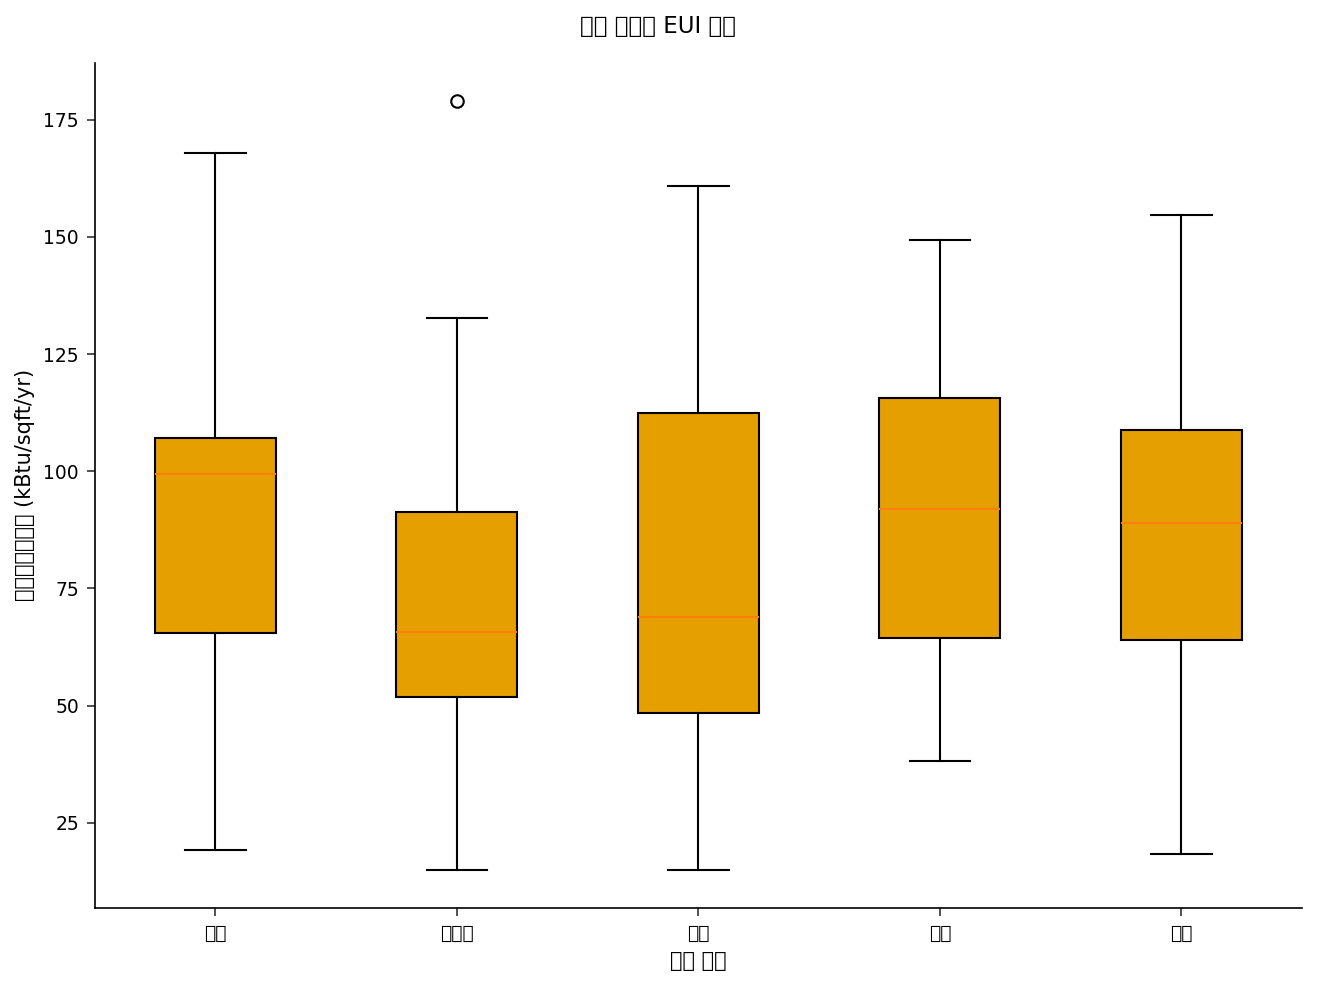

In [3]:
/* --------------------------------------------------------
   건물 유형별 EUI 분포
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS 라벨='건물 유형';
    YAXIS 라벨='에너지사용강도 (kBtu/sqft/yr)';
    제목 '건물 유형별 EUI 분포';
실행;


---

In [4]:
/* --------------------------------------------------------
   효율 지표 표준화
   -------------------------------------------------------- */
처리 표준 데이터=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
실행;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K-평균 군집화: REPLACE=FULL, k=3
   -------------------------------------------------------- */
처리 FASTCLUS 데이터=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    라벨 eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)';
    제목 '건물 효율 군집화: k=3 REPLACE=FULL';
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K-평균 군집화: REPLACE=FULL, k=4
   -------------------------------------------------------- */
처리 FASTCLUS 데이터=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    라벨 eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)';
    제목 '건물 효율 군집화: k=4 REPLACE=FULL';
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4                  34         0.7362             2.5888              3         2.0389

                                    


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K-평균 군집화: REPLACE=FULL, k=5
   -------------------------------------------------------- */
처리 FASTCLUS 데이터=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    라벨 eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)';
    제목 '건물 효율 군집화: k=5 REPLACE=FULL';
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4                  24         0.7338             2.6294              5         2.0344
5                  17         0.6469 


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K-평균 군집화: REPLACE=FULL, k=6
   -------------------------------------------------------- */
처리 FASTCLUS 데이터=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    라벨 eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)';
    제목 '건물 효율 군집화: k=6 REPLACE=FULL';
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4                  24         0.6557             2.4999              3         1.8819
5                  17         0.7471 


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   k=3-6 구간의 군집 품질 비교
   군집 내 R-제곱과 최소 군집 크기 계산
   -------------------------------------------------------- */
%macro cluster_quality(k);
처리 빈도 데이터=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (개명=(count=n_buildings));
실행;

처리 SQL NOPRINT;
    선택 MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);



NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                                  건물 효율 등급 프로파일 (k=4)                                                   

                                                  The MEANS Procedure

                                     Analysis Variable : eui 에너지사용강도(EUI)

                                                 N
                                     군집        Obs             Mean         Std Dev
                                     ----------------------------------------------
                                     1          23       63.7782609      31.5423086
                                     2          17      122.5941176      36.0679995
                                     3          26       94.0076923      30.8825378
                                     4          34       72.3911765      31.7411154
                                     ----------------------------------------------

                                      Analysis Variable : hvac_efficiency HVAC 효율(COP)

    


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


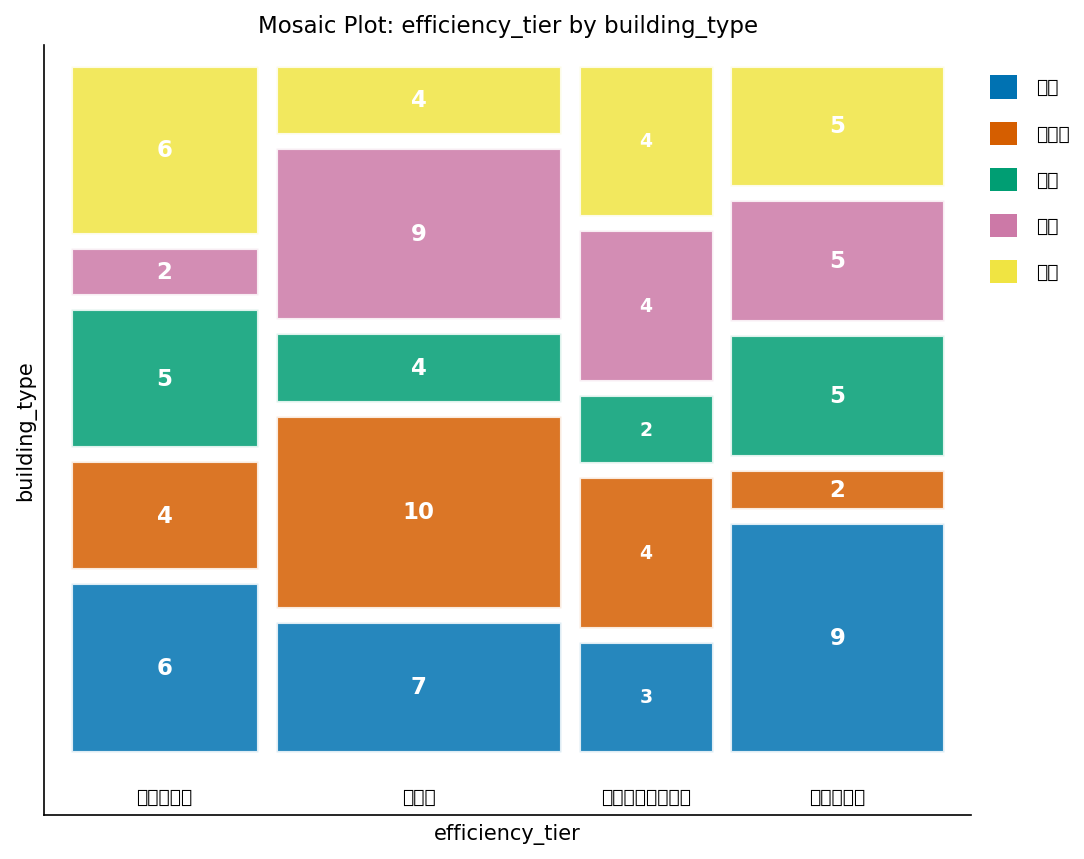

In [10]:
/* --------------------------------------------------------
   선정된 k=4 해 프로파일링
   -------------------------------------------------------- */
데이터 work.bldg_profiled;
    결합 work.building_metrics
          work.bldg_clust4 (유지=building_id CLUSTER distance);
    기준 building_id;
실행;

처리 평균 데이터=work.bldg_profiled mean std;
    분류 CLUSTER;
    변수 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    라벨 CLUSTER='군집'
          eui='에너지사용강도(EUI)' hvac_efficiency='HVAC 효율(COP)'
          envelope_r_value='외피 단열성능(R값)' lighting_wpf='조명 전력밀도(W/sqft)'
          renewable_pct='재생에너지 비율(%)' building_age='건물 연령(년)';
    제목 '건물 효율 등급 프로파일 (k=4)';
실행;

/* 관측된 k=4 중심값을 근거로 효율 등급을 라벨링:
   군집 4 = 최고 HVAC(3.89), 낮은 EUI -> 고효율
   군집 2 = 최고 재생에너지 비율(28%)이지만 최고 EUI -> 재생에너지집중형
   군집 3 = 최고 조명 부하, 약한 HVAC, 중간 EUI -> 조명부하형
   군집 1 = 낮은 EUI이지만 가장 약한 HVAC + 가장 얇은 외피 -> 개보수우선 */
데이터 work.bldg_tiered;
    설정 work.bldg_profiled;
    길이 efficiency_tier $30;
    만약 CLUSTER = 4 이면 efficiency_tier = '고효율';
    아니면 만약 CLUSTER = 2 이면 efficiency_tier = '재생에너지집중형';
    아니면 만약 CLUSTER = 3 이면 efficiency_tier = '조명부하형';
    아니면 만약 CLUSTER = 1 이면 efficiency_tier = '개보수우선';
실행;

처리 빈도 데이터=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    라벨 efficiency_tier='효율 등급' building_type='건물 유형';
    제목 '건물 유형별 효율 등급';
실행;


---

### 해석

`REPLACE=FULL` 옵션으로 모든 k 값이 깔끔하게 수렴했다. 네 가지 해에 걸쳐 전체 R-제곱은
k가 커질수록 단조 증가했다 — 0.305(k=3), 0.410(k=4), 0.459(k=5), 0.515(k=6) — 반면 유사 F
통계량은 **k=4에서 22.23으로 정점**을 찍은 뒤 감소했다(k=5에서 20.13, k=6에서 19.93). k=4에서의
최소 군집 크기 17개 건물(k=5의 13개, k=6의 10개와 비교)을 함께 고려하면, **k=4 해**가 분리도와
등급 안정성 사이에서 가장 좋은 균형을 제공하므로 아래에서 이를 프로파일링한다.

k=4의 네 군집은 뚜렷하게 구분되는 효율 프로파일에 대응한다 (위 PROC MEANS 프로파일의 평균값
기준).

- **고효율 (군집 4, n=34):** 가장 잘 갖춰진 그룹 — 낮거나 중간 정도의 EUI 72.4 kBtu/sqft/yr에서
  가장 높은 HVAC 효율(COP 3.89)을 보이며, 적절한 외피 성능(R 18.8)과 적당한 재생에너지 비율
  (11.0%)을 가진다.
- **재생에너지집중형 (군집 2, n=17):** 절대 소비량이 가장 높은 그룹(EUI 122.6)이지만 재생에너지
  비율도 단연 가장 높다(28.2%), HVAC은 중간 수준(COP 3.42)이다. 높은 소비량과 자가 발전이
  함께 나타난다.
- **조명부하형 (군집 3, n=26):** 중간 EUI(94.0)는 가장 높은 조명 전력밀도(1.35 W/sqft)와 두
  번째로 약한 HVAC(COP 2.42)에 기인하며, 외피는 가장 두껍다(R 19.6).
- **개보수우선 (군집 1, n=23):** 서류상 EUI는 낮지만(63.8) HVAC이 가장 약하고(COP 2.28) 외피가
  가장 얇다(R 12.5) — 규모가 작거나 사용량이 적지만 설비가 열악한 건물로, 외피와 HVAC
  개보수의 가장 확실한 후보이다.

등급별-건물유형 교차표를 보면 사무용(10)과 창고(9)가 고효율 등급을 지배하는 반면, 병원은
조명부하형 등급에 집중된다(26개 중 9개). 개보수우선 등급은 유형 전반에 걸쳐 분포하며, 병원과
학교가 각각 6개씩으로 가장 많다(23개 중). 프로그램 설계 관점에서, 개보수우선 23개와 조명부하형
26개 건물은 각각 HVAC 및 조명 인센티브의 자연스러운 대상이며, 이미 현장에서 발전 중인
재생에너지집중형 17개 건물은 추가 발전 리베이트보다 수요 절감 프로그램에 더 적합하다.


---

In [11]:
/* --------------------------------------------------------
   건물 효율 등급과 중심값 프로파일 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
실행;

처리 EXPORT 데이터=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 대외비
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>